<a href="https://colab.research.google.com/github/nasif-raihan/GSU/blob/main/CSCI_7090_Module2_Lab2_Morphology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 2 — Morphological Operations (Labs)
**Computer Vision**

Runs in Colab or local Jupyter — **no webcam, no `cv2.imshow`**. Morphology is demonstrated on a static **binary** image (that is where erosion, dilation, opening, closing, and gradient are clearest).

## Setup
Builds a binary shape image with salt noise (stray white specks) and small black holes, so each operation has a visible effect.

In [ ]:
# Optional (Colab):
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path
import cv2, numpy as np
import matplotlib.pyplot as plt

Mounted at /content/drive


binary image: (300, 300) values: [  0 255]


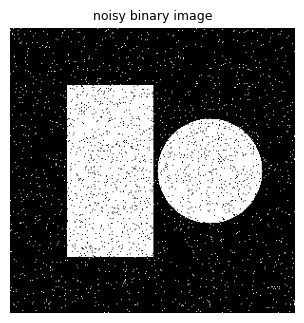

In [ ]:
def show_row(items, cmap="gray"):
    n=len(items); plt.figure(figsize=(3.2*n, 3.3))
    for i,(im,t) in enumerate(items):
        ax=plt.subplot(1,n,i+1)
        if im.ndim==2: ax.imshow(im, cmap=cmap, vmin=0, vmax=255)
        else:          ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        ax.set_title(t, fontsize=9); ax.axis("off")
    plt.tight_layout(); plt.show()

# Build a clean BINARY test image (morphology is clearest on binary images).
rng = np.random.default_rng(0)
binary = np.zeros((300, 300), np.uint8)
cv2.rectangle(binary, (60, 60),  (150, 240), 255, -1)
cv2.circle(binary,    (210, 150), 55, 255, -1)

# Add salt noise (stray white specks) and pepper holes (black gaps inside objects)
salt = rng.random(binary.shape) < 0.02
binary[salt] = 255
holes = (rng.random(binary.shape) < 0.05) & (binary == 255)
binary[holes] = 0

print("binary image:", binary.shape, "values:", np.unique(binary))
show_row([(binary, "noisy binary image")])

## Structuring element (kernel)
Morphology slides a **structuring element** over the image. A 5×5 square is a common default.

In [ ]:
kernel = np.ones((5, 5), np.uint8)   # or cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
print(kernel)

[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]


## Erosion & Dilation
**Erosion** keeps a pixel white only if *all* neighbours under the kernel are white → shrinks objects, removes specks. **Dilation** sets a pixel white if *any* neighbour is white → grows objects, fills gaps.

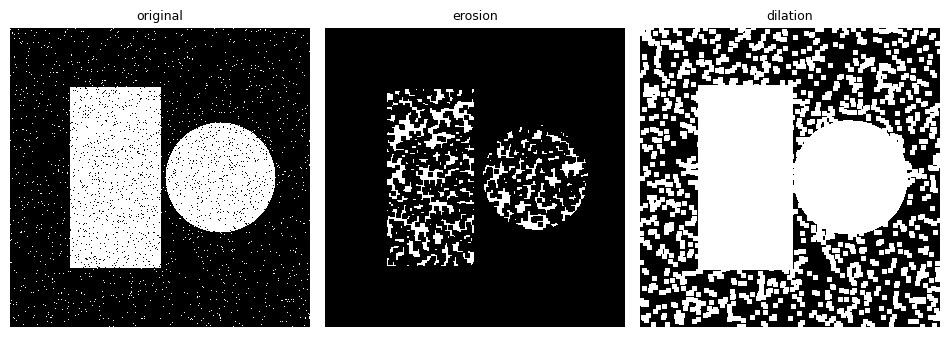

In [ ]:
erosion  = cv2.erode(binary,  kernel, iterations=1)
dilation = cv2.dilate(binary, kernel, iterations=1)
show_row([(binary,"original"), (erosion,"erosion"), (dilation,"dilation")])

## Opening = erosion → dilation
Removes small **white** noise (the salt specks) while keeping object size roughly intact.

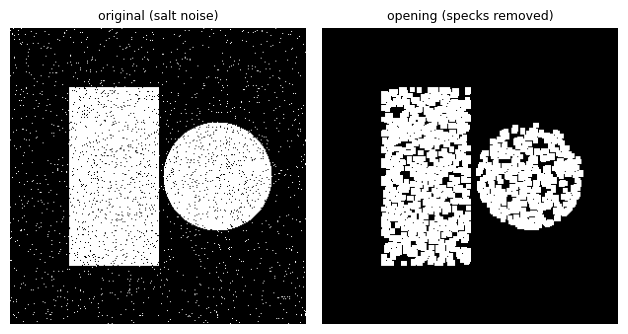

In [ ]:
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
show_row([(binary,"original (salt noise)"), (opening,"opening (specks removed)")])

## Closing = dilation → erosion
Fills small **black** holes/gaps inside white objects.

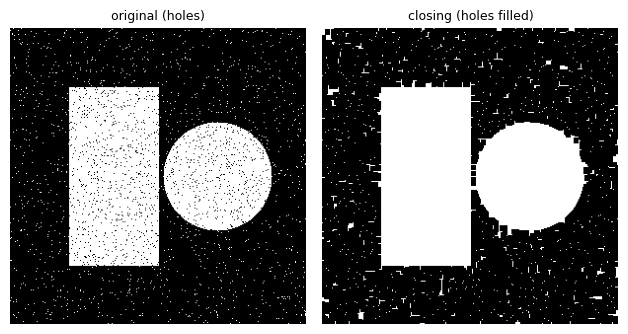

In [ ]:
closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
show_row([(binary,"original (holes)"), (closing,"closing (holes filled)")])

## Gradient = dilation − erosion
Highlights object boundaries (a morphological edge detector).

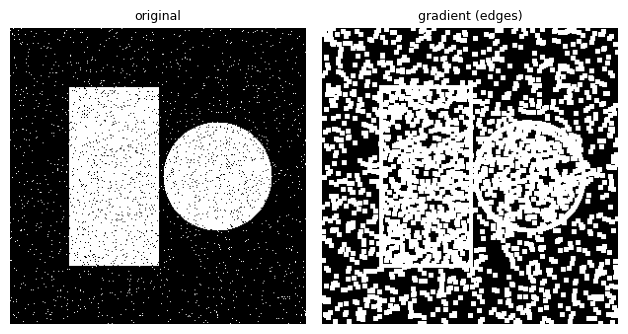

In [ ]:
gradient = cv2.morphologyEx(binary, cv2.MORPH_GRADIENT, kernel)
show_row([(binary,"original"), (gradient,"gradient (edges)")])

## Putting it together
Clean the noisy mask (opening then closing), then outline it (gradient) — a typical preprocessing chain for document/object extraction.

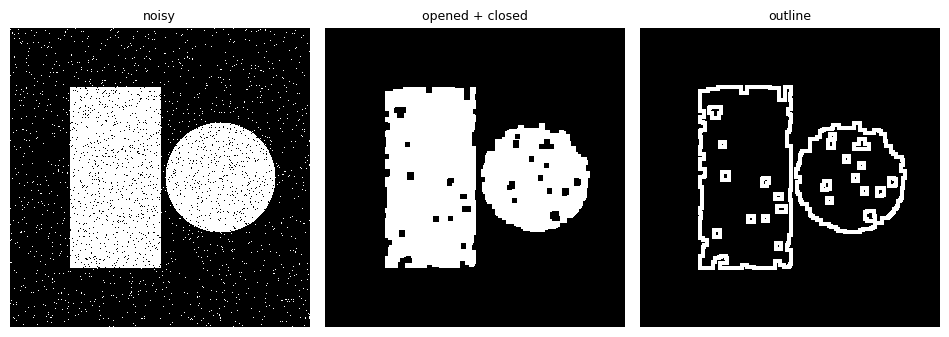

In [ ]:
clean = cv2.morphologyEx(binary, cv2.MORPH_OPEN,  kernel)
clean = cv2.morphologyEx(clean,  cv2.MORPH_CLOSE, kernel)
outline = cv2.morphologyEx(clean, cv2.MORPH_GRADIENT, kernel)
show_row([(binary,"noisy"), (clean,"opened + closed"), (outline,"outline")])